# КЭЭ классическая - Бинарная классификация

## Описание задачи

Пациенты с гемодинамически значимым стенозом внутренней сонной артерии (ВСА) являются кандидатами на выполнение каротидной ангиопластики со каротидной эндартерэктомией (КЭЭ) – эндоваскулярного вмешательства, направленного на восстановление просвета сосуда. Несмотря на меньшую инвазивность по сравнению с каротидной ангиопластикой со стентированием (КАС), КЭЭ сопряжена с риском периоперационных осложнений, включая ишемический инсульт, транзиторную ишемическую атаку (ТИА), гиперперфузионный синдром, тромбоз стента, острый инфаркт миокарда, гематому в месте доступа и острую почечную недостаточность.

Частота этих событий относительно невысока, однако их клиническая значимость диктует необходимость индивидуальной предоперационной оценки риска. Для хирурга принципиально важно располагать инструментом, позволяющим на основе рутинно собираемых анамнестических и клинико-инструментальных данных прогнозировать как сам факт возникновения осложнения, так и его вероятную степень тяжести.

В силу секретности медицинских данных, исходный датасет прикрепляться не будет, поэтому результаты воспроизвести не удасться 

В рамках настоящего ноутбука разрабатывается модель машинного обучения для пациентов, которым планируется КЭЭ классическая - один из видов КЭЭ. Модель предназначена для бинарной классификации на следующие классы: отсутствие любого осложнения (0) и наличие осложнения любых осложнений (1).

Исходные данные характеризуются значительным дисбалансом в пользу негативных исходов (осложнения отсутствуют). Применение стандартных классификаторов без учёта дисбаланса приводит к тривиальному решению – предсказанию класса «0» с высокой accuracy, не имеющему клинической ценности.

Для компенсации дисбаланса в экспериментах используются следующие подходы:

1) SMOTE (Synthetic Minority Over-sampling Technique) – генерация синтетических примеров миноритарного класса;
2) class_weight – назначение весов, обратно пропорциональных частоте классов, непосредственно в функции потерь модели.

Исходное признаковое пространство включает 17 переменных: 
1. Возраст пациента – числовой тип данных; 
2. Пол пациента – категориальный тип данных («м» - мужской, «ж» - женский); 
3. Степень стеноза внутренней сонной артерии (в %) – категориальный тип данных (100, 90-99, 70-89, 50-69, 0-49); 
4. Степень стеноза контралатеральной внутренней сонной артерии (в %) – категориальный тип данных (100, 90-99, 70-89, 50-69, 0-49, с/п КЭЭ, с/п ТБА); 
5. Кальциноз бифуркации общей сонной артерии (степень) – категориальный тип данных (0 – нет, 1 – невыраженный (вкрапления), 2 – циркулярный); 
6. Патологическая извитость внутренней сонной артерии – категориальный тип данных (0 – нет 1 – да); 
7. Симптомность стеноза внутренней сонной артерии - категориальный тип данных (0 – нет 1 – да);
8. Хроническая сосудисто-мозговая недостаточность (степень) - категориальный тип данных (0, 1, 2, 3, 4); 
9. Стенокардия ФК (функциональный класс) - категориальный тип данных (0, 1, 2, 3, 4); 
10. Перенесенный инфаркт миокарда - категориальный тип данных (0 – нет 1 – да); 
11. Нарушения ритма сердца – категориальный тип данных (0 -нет 1 - да); 
12. Хроническая сердечная недостаточность (стадия) – категориальный тип данных (0 – нет, 1, 2 а, 2 б, 3); 
13. Функциональный класс по NYHA – (0 – нет 1 - I ФК 2 - II ФК 3 - III ФК 4 - IV ФК); 
14. Сахарный диабет – категориальный тип данных (0 – нет 1 – да); 
15. Хроническая обструктивная болезнь легких (стадия) – категориальный тип данных (0 – нет 1 – 1 степень 2 – 2 степень 3 – 3 степень); 
16. Наличие ОНМК в анамнезе - категориальный тип данных (0 – нет 1 – однократно 2 – повторные); 
17. Время окклюзии внутренней сонной артерии (в минутах) – числовой тип данных. Данный параметр характерен только для видов КЭЭ.

Для повышения обобщающей способности моделей исследуется влияние трёх методов уменьшения размерности и отбора признаков:
1) PCA (Principal Component Analysis) – линейное преобразование, сохраняющее максимальную дисперсию данных (число компонент выбирается по критерию 95% объяснённой дисперсии).
2) LDA (Linear Discriminant Analysis) – проекция на подпространство, максимизирующее разделимость классов (для бинарной задачи – на одну ось).
3) SBS (Sequential Backward Selection) – жадный алгоритм исключения признаков, оценивающий качество модели (ROC-AUC) на кросс-валидации после каждого удаления.

Каждый из этих методов применяется к одним и тем же исходным данным независимо, с возвратом к исходной матрице признаков перед каждым преобразованием. Такая схема позволяет корректно сравнить их влияние на итоговые метрики.

Для каждого варианта предобработки обучаются следующие классификаторы:
1. Логистическая регрессия (Logistic Regression);
2. Алгоритм k-ближайших соседей (K-nearst Neighbours);
3. Метод опорных векторов (SVM);
4. Случайный лес (Random Forest);
5. AdaBoost;
6. XGBoost;
7. Многослойный персептрон (MLP).

Оценка качества производится на отложенной тестовой выборке (30% данных для первых 6 моделей и 15% для MLP) с использованием метрик: accuracy, precision, recall, F1-score (macro и weighted), ROC-AUC, MCC (Matthews correlation coefficient).

Подбор гиперпараметров осуществлялся с помощью двух алгоритмов алгоритмов - GridSearch и HalvingGridSearch. В основном использовался первый, второй применялся только для некоторых моделей ансамблей и SVM, когда вычисления проходили крайне долго

В качестве подхода способа обучения моделей классического машинного обучения рассматривались стратифицированная кросс-валидация с 5К-фолдами с разбиением на обучающую и тестовую выборки в соотношении 70:30 соответственно. Для обучения нейронных сетей использовалась стандартное разбиение на обучающую, валидационную и тестовую выборки с разбиением в соотношении 70:15:15 вместе с созданием искусственных синтетических примеров.

## Импортирование необходимых библиотек и объявление вспомогательных классов и функций

Здесь импортируются все необходимые библиотеки для обучения моделей машинного обучения и обработки данных, а также вводятся вспомогательные функции

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, validation_curve, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, make_scorer, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.base import clone
from skorch import NeuralNetClassifier
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline
from collections import Counter
from numpy import interp
from tabulate import tabulate
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.model_selection import HalvingGridSearchCV

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
import xgboost as xgb
from scikeras.wrappers import KerasClassifier
from keras import models, layers, initializers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

In [3]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle
import json
import joblib

In [17]:
class SBS:
    """Реализация алгоритма SBS"""
    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    
    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        
        X_train, X_test, y_train, y_test = \
            train_test_split(X, y, test_size = self.test_size, random_state = self.random_state)
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]
        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_,  r=dim-1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p) 
                scores.append(score) 
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score

In [18]:
def rename_columns_categorical(df):
    """Переименование колонок для категореальных признаков после применения onehotencoder"""
    categorical_features = list(df.columns)[:-2]
    
    for i in range (len(categorical_features)):
         categorical_features[i]= categorical_features[i].replace("onehotencoder__", "")  
    return categorical_features 

In [19]:
def grid_search_for_model(estimator, param_grid, X_train, y_train, cv=20):
    """Подбор гиперпараметров с помощью GridSearch"""
    
    gs = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring='recall', cv=cv, refit=True , verbose=1, n_jobs=1)
    gs = gs.fit(X_train, y_train)
    print(gs.best_score_)
    print(gs.best_params_)

In [20]:
def select_index_features(sbs, index, X_train, X_test): 
    """Выбор признаков, полученных алгоритмом SBS, по заданному индексу"""
    
    k = list(sbs.subsets_[index])
    X_train_sbs = X_train[:, k].copy()
    X_test_sbs = X_test[:, k].copy()
    return X_train_sbs, X_test_sbs 

In [21]:
def model_training(estimator, X_train, y_train, n_splits=20, cv=5):
    """Обучение моделей классического машинного обучения"""
    
    kfold = StratifiedKFold(n_splits=n_splits).split(X_train, y_train)
    scores = []
    
    if hasattr(X_train, 'iloc'):
        for k, (train, test) in enumerate(kfold):
            estimator.fit(X_train.iloc[train], y_train.iloc[train] if hasattr(y_train, 'iloc') else y_train[train])
            score = estimator.score(X_train.iloc[test], y_train.iloc[test] if hasattr(y_train, 'iloc') else y_train[test])
            scores.append(score)
            print(f'Выборка: {k+1:02d}, '
                  f'Распр. кл.: {np.bincount(y_train.iloc[test] if hasattr(y_train, 'iloc') else y_train[test])}, '
                  f'Точн.: {score:.3f}')
    else:
        for k, (train, test) in enumerate(kfold):
            estimator.fit(X_train[train], y_train[train])
            score = estimator.score(X_train[test], y_train[test])
            scores.append(score)
            print(f'Выборка: {k+1:02d}, '
                  f'Распр. кл.: {np.bincount(y_train[test])}, '
                  f'Точн.: {score:.3f}')
    
    final_scores = cross_val_score(estimator=estimator, X=X_train, y=y_train, cv=cv, n_jobs=1)
    print(f'Точность по CV: {np.mean(final_scores):.3f} '
          f'+/- {np.std(final_scores):.3f}')
    
    return estimator

In [22]:
def calculate_metrics(y_true, y_pred, metrics, average_methods):
    """Вычисление метрик"""
    
    metrics_dict = {}
    
    for metric in metrics:
        if metric == 'accuracy':
            metrics_dict['accuracy'] = accuracy_score(y_true, y_pred)
        
        elif metric in ['precision', 'recall', 'f1']:
            for avg in average_methods:
                metric_func = {
                    'precision': precision_score,
                    'recall': recall_score,
                    'f1': f1_score
                }[metric]
                try:
                    metrics_dict[f'{metric}_{avg}'] = metric_func(y_true, y_pred, average=avg)
                except:
                    metrics_dict[f'{metric}_{avg}'] = np.nan
        
        elif metric == 'mcc':
            try:
                metrics_dict['mcc'] = matthews_corrcoef(y_true, y_pred)
            except:
                metrics_dict['mcc'] = np.nan
    
    return metrics_dict

In [23]:
def print_results_table(results, metrics, average_methods):
    """Создание таблицы с посчитанными значениями метрик"""
    
    table_data = []
    headers = ['Dataset']
    
    for metric in metrics:
        if metric == 'accuracy':
            headers.append('Accuracy')
        elif metric == 'mcc':
            headers.append('MCC')
        else:
            for avg in average_methods:
                headers.append(f'{metric.capitalize()} ({avg})')
    
    for dataset, metrics_dict in results.items():
        row = [dataset]
        for metric in metrics:
            if metric == 'accuracy':
                row.append(f"{metrics_dict.get('accuracy', 0):.3f}")
            elif metric == 'mcc':
                row.append(f"{metrics_dict.get('mcc', 0):.3f}")
            else:
                for avg in average_methods:
                    key = f'{metric}_{avg}'
                    row.append(f"{metrics_dict.get(key, 0):.3f}")
        table_data.append(row)
    
    print(tabulate(table_data, headers=headers, tablefmt='grid', stralign='center'))

In [24]:
def evalute_model(estimator, data, metrics=None, average_methods=['micro', 'macro']):
    """Вывод посчитанных метрик и визуализация матрицы ошибок"""
    
    if metrics is None:
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'mcc']
    
    results = {}
    
    fig, axes = plt.subplots(1, len(data), figsize=(5*len(data), 4))
    if len(data) == 1:
        axes = [axes]
    
    for idx, (name, (X, y)) in enumerate(data.items()):
        y_pred = np.round(estimator.predict(X))
        
        confmat = confusion_matrix(y_true=y, y_pred=y_pred)
        axes[idx].matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
        for i in range(confmat.shape[0]):
            for j in range(confmat.shape[1]):
                axes[idx].text(x=j, y=i, s=confmat[i, j], va='center', ha='center', fontsize=12)
        
        axes[idx].xaxis.set_ticks_position('bottom')
        axes[idx].set_xlabel('Предсказанная метка')
        axes[idx].set_ylabel('Истинная метка')
        axes[idx].set_title(f'Матрица ошибок - {name}')
        
        results[name] = calculate_metrics(y, y_pred, metrics, average_methods)
    
    plt.tight_layout()
    plt.show()
    
    print_results_table(results, metrics, average_methods)
    
    return results

In [25]:
def ROC_curve(estimator, X_train, X_test, y_train, y_test, n_splits=20):
    """Построение графиков ROC-кривых"""
    
    cv = list(StratifiedKFold(n_splits=n_splits).split(X_train, y_train))
    
    plt.figure(figsize=(7, 5))
    mean_tpr = 0.0
    mean_fpr = np.linspace(0, 1, 100)
    
    use_pandas = hasattr(X_train, 'iloc')
    
    for i, (train, test) in enumerate(cv):
        if use_pandas:
            X_train_fold = X_train.iloc[train]
            y_train_fold = y_train.iloc[train] if hasattr(y_train, 'iloc') else y_train[train]
            X_val_fold = X_train.iloc[test]
            y_val_fold = y_train.iloc[test] if hasattr(y_train, 'iloc') else y_train[test]
        else:
            X_train_fold = X_train[train]
            y_train_fold = y_train[train]
            X_val_fold = X_train[test]
            y_val_fold = y_train[test]
        
        probas = estimator.fit(X_train_fold, y_train_fold).predict_proba(X_val_fold)
        fpr, tpr, _ = roc_curve(y_val_fold, probas[:, 1], pos_label=1)
        
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        mean_tpr[0] = 0.0
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Выборка ROC {i+1} (area={roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='Случайный выбор (area=0.5)')
    plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='black', label='Идеальная производительность (area=1.0)')
    
    mean_tpr /= len(cv)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, 'k--', label=f'Средн. ROC (area = {mean_auc:.2f})', lw=2)
    
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Доля ложноположительных прогнозов')
    plt.ylabel('Доля истинно положительных прогнозов')
    plt.legend(loc='lower right')
    plt.show()

In [26]:
def ROC_curve_for_keras(data, model):
    """Построение графиков ROC-кривых для Keras"""
    
    for name, (X_data, y_data) in data.items():
        y_prob = model.predict(X_data)
        fpr, tpr, thresholds = roc_curve(y_data, y_prob)
        auc = roc_auc_score(y_data, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curves for Train, Validation, and Test Data')
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
def manual_keras_grid_search(X_train, y_train, param_grid, cv=5):
    """Реализация алгоритма GridSearch для Keras"""
    
    best_score = -1
    best_params = None
    results = []
    
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    param_combinations = list(ParameterGrid(param_grid))
    
    print(f"Всего комбинаций: {len(param_combinations)}")
    
    for i, params in enumerate(param_combinations):
        print(f"\nКомбинация {i+1}/{len(param_combinations)}: {params}")
        
        cv_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
            
            model = Sequential()
            
            model.add(Input(shape=(X_train.shape[1],)))
            
            model.add(Dense(params['hidden_layer_sizes'][0],  
                           activation=params['activation'], 
                           kernel_regularizer=l1_l2(l1=params['l1_reg'], l2=params['l2_reg'])))
            if params['use_batch_norm']:
                 model.add(BatchNormalization())
             
            if params['dropout_rate'] > 0:
                model.add(Dropout(params['dropout_rate']))
            
            for units in params['hidden_layer_sizes'][1:]:
                model.add(Dense(units, activation=params['activation'], 
                                kernel_regularizer=l1_l2(l1=params['l1_reg'], l2=params['l2_reg'])))
                if params['use_batch_norm']:
                     model.add(BatchNormalization())
             
                if params['dropout_rate'] > 0:
                    model.add(Dropout(params['dropout_rate']))
            
            model.add(Dense(1, activation='sigmoid'))
            if params['optimizer'] == 'adam':
                optimizer = Adam(learning_rate=params['learning_rate'])
            elif params['optimizer'] == 'rmsprop':
                optimizer = RMSprop(learning_rate=params['learning_rate'])
            elif params['optimizer'] == 'sgd':
                optimizer = SGD(learning_rate=params['learning_rate'], momentum=0.9)
            else:
                optimizer = Adam(learning_rate=params['learning_rate'])
            
            model.compile(loss='binary_crossentropy', 
                         optimizer=optimizer,
                         metrics=['accuracy'])
            
            history = model.fit(X_train_fold, y_train_fold,
                              epochs=params['epochs'],
                              batch_size=params['batch_size'],
                              verbose=0,
                              validation_data=(X_val_fold, y_val_fold))
            
            y_pred = (model.predict(X_val_fold) > 0.5).astype(int)
            score = recall_score(y_val_fold, y_pred)
            cv_scores.append(score)
            
            print(f"  Fold {fold+1}: recall = {score:.4f}")
        
        mean_score = np.mean(cv_scores)
        print(f"  Средний recall: {mean_score:.4f}")
        
        results.append({
            'params': params,
            'score': mean_score
        })
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
    
    results.sort(key=lambda x: x['score'], reverse=True)
    
    print("5 лучших результатов:")
    for i, res in enumerate(results[:5]):
        print(f"{i+1}. Score: {res['score']:.4f}, Params: {res['params']}")
    
    print(f"Лучший результат: {best_score:.4f}")
    print(f"Лучшие параметры: {best_params}")
    
    return best_score, best_params, results

In [28]:
f1_scorer_macro = lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro')
f1_scorer_micro = lambda y_true, y_pred: f1_score(y_true, y_pred, average='micro')
pre_scorer_macro = lambda y_true, y_pred: precision_score(y_true, y_pred, average='macro')
pre_scorer_micro = lambda y_true, y_pred: precision_score(y_true, y_pred, average='micro')
rec_scorer_macro = lambda y_true, y_pred: recall_score(y_true, y_pred, average='macro')
rec_scorer_micro = lambda y_true, y_pred: recall_score(y_true, y_pred, average='micro')
mcc_scorer_micro = lambda y_true, y_pred: matthews_corrcoef(y_true, y_pred, average='micro')
mcc_scorer_macro = lambda y_true, y_pred: matthews_corrcoef(y_true, y_pred, average='macro')

## Загрузка и предварительная обработка набора данных

Здесь происходит загрузка имеющегося набора данных, удаление лишних столбцов, предобработка данных (кодирование категореальных переменных и стандартизация числовых признаков)

In [29]:
data_kee_classic = pd.read_excel('Data_Multiclass.xlsx', sheet_name='KEE - classic')

In [30]:
label_cols = ['onmk', 'tia', 'thrombosis', 'oim', 'pneumonia', 
              'post_puncture_hematoma', 'cranial_nerve_damage', 'bleeding']
data_kee_classic = data_kee_classic.drop(columns=label_cols)

In [31]:
data_kee_classic = data_kee_classic.drop(columns=['п/п','type_of_surgical_intervention', 'type_of_surgical_intervention', 'type_of_CEE'])

In [32]:
categorical_features = ['gender', 'degree_of_stenosis_of_the_internal_carotid_artery',	
                        'stenosis_degree_of_the_contralateral_internal_carotid_artery',	
                        'calcinosis', 'pivsa', 'symptoms_of_internal_carotid_artery_stenosis',	
                        'hsmn',	'angina_pectoris_FC', 'pim', 'heart_rhythm_disturbances', 'hsn',	
                        'FC_by_NYHA', 'sd',	'hobl', 'history_of_oncological_cancer']
numeric_features = ['age']

In [33]:
X = data_kee_classic.drop(columns=['complication']).astype(str)
y = data_kee_classic['complication']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [35]:
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', scaler, numeric_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.fit(X)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test = pd.DataFrame(X_test_transformed, columns=feature_names)

print(X_train)
print(X_test)

joblib.dump(preprocessor, 'preprocessor_kee_classic_final.pkl')

    gender_ж gender_м degree_of_stenosis_of_the_internal_carotid_artery_50-69  \
0        0.0      1.0                                                0.0        
1        0.0      1.0                                                0.0        
2        0.0      1.0                                                0.0        
3        0.0      1.0                                                0.0        
4        0.0      1.0                                                0.0        
..       ...      ...                                                ...        
131      0.0      1.0                                                0.0        
132      0.0      1.0                                                0.0        
133      1.0      0.0                                                1.0        
134      0.0      1.0                                                0.0        
135      0.0      1.0                                                0.0        

    degree_of_stenosis_of_t

['preprocessor_kee_classic_final.pkl']

In [36]:
X

,gender,age,degree_of_stenosis_of_the_internal_carotid_artery,stenosis_degree_of_the_contralateral_internal_carotid_artery,calcinosis,pivsa,symptoms_of_internal_carotid_artery_stenosis,hsmn,angina_pectoris_FC,pim,heart_rhythm_disturbances,hsn,FC_by_NYHA,sd,hobl,history_of_oncological_cancer,occlusion_time
0,м,72,90-99,90-99,0,1,0,3,3,1,0,2 а,4,0,1,0,22
1,м,52,90-99,0-49,0,0,0,1,0,0,0,1,0,0,0,0,23
2,м,54,70-89,0-49,1,1,1,4,2,1,0,2 а,2,0,0,1,18
3,ж,62,70-89,50-69,0,1,0,3,3,1,0,2 б,3,0,0,0,25
4,м,64,70-89,0-49,1,0,0,3,0,0,0,2 а,0,0,0,0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,ж,51,50-69,0-49,1,0,1,4,0,0,0,1,0,0,0,1,41
191,м,61,70-89,50-69,2,0,1,4,0,0,0,1,1,1,0,1,36
192,м,59,70-89,с/п КЭЭ,2,0,1,3,0,0,0,1,2,1,0,0,55
193,м,77,70-89,0-49,1,0,1,2,0,0,0,1,2,0,0,0,30


In [37]:
print(X.columns.tolist())

['gender', 'age', 'degree_of_stenosis_of_the_internal_carotid_artery', 'stenosis_degree_of_the_contralateral_internal_carotid_artery', 'calcinosis', 'pivsa', 'symptoms_of_internal_carotid_artery_stenosis', 'hsmn', 'angina_pectoris_FC', 'pim', 'heart_rhythm_disturbances', 'hsn', 'FC_by_NYHA', 'sd', 'hobl', 'history_of_oncological_cancer', 'occlusion_time']


In [38]:
X_train

,gender_ж,gender_м,degree_of_stenosis_of_the_internal_carotid_artery_50-69,degree_of_stenosis_of_the_internal_carotid_artery_70-89,degree_of_stenosis_of_the_internal_carotid_artery_80-89,degree_of_stenosis_of_the_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_0-49,stenosis_degree_of_the_contralateral_internal_carotid_artery_50-69,stenosis_degree_of_the_contralateral_internal_carotid_artery_70-89,stenosis_degree_of_the_contralateral_internal_carotid_artery_90-99,...,sd_1,hobl_0,hobl_1,hobl_2,hobl_3,history_of_oncological_cancer_0,history_of_oncological_cancer_1,history_of_oncological_cancer_2,age,occlusion_time
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.591074,32
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.898023,28
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.176299,18
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.591074,35
4,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.483248,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.591074,18
132,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.437599,29
133,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.022824,25
134,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.358447,18


## Уменьшение размерности с помощью линейного дискриминантного анализа и обучение различных типов моделей

In [116]:
lda = LDA(solver= 'svd')

In [117]:
y_train_lda = y_train.values.ravel()
y_test_lda = y_test.values.ravel()
X_train_lda = lda.fit_transform(X_train, y_train_lda)
X_test_lda = lda.transform(X_test)

In [118]:
data = {"Train": (X_train_lda, y_train_lda),
        "Test": (X_test_lda, y_test_lda)}

### Логистическая регрессия

In [32]:
lr = LogisticRegression(random_state=1)
param_range = [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 50.0, 100.0]
param_grid_lr = [{'C': param_range, 'solver': ['lbfgs'], 'penalty': ['l2'], 'max_iter': [100, 200, 300, 500, 1000, 10000] }, 
             {'C': param_range, 'solver': ['liblinear'], 'penalty': ['l2', 'l1'], 'max_iter': [100, 200, 300, 500, 1000, 10000] }, 
             ]
grid_search_for_model(lr, param_grid_lr, X_train_lda, y_train_lda)

Fitting 20 folds for each of 144 candidates, totalling 2880 fits
0.7
{'C': 0.001, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [38]:
lr = LogisticRegression(C = 0.001, max_iter= 100, penalty = 'l2', solver = 'liblinear')
lr1 = model_training(lr, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20) 

Выборка: 01, Распр. кл.: [5 2], Точн.: 1.000
Выборка: 02, Распр. кл.: [5 2], Точн.: 1.000
Выборка: 03, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 04, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 05, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 06, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 07, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 08, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 09, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 10, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 11, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 12, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 13, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 14, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 15, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 16, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 17, Распр. кл.: [5 1], Точн.: 1.000
Выборка: 18, Распр. кл.: [5 1], Точн.: 0.833
Выборка: 19, Распр. кл.: [5 1], Точн.: 0.667
Выборка: 20, Распр. кл.: [5 1], Точн.: 1.000
Точность по CV: 0.911 +/- 0.111


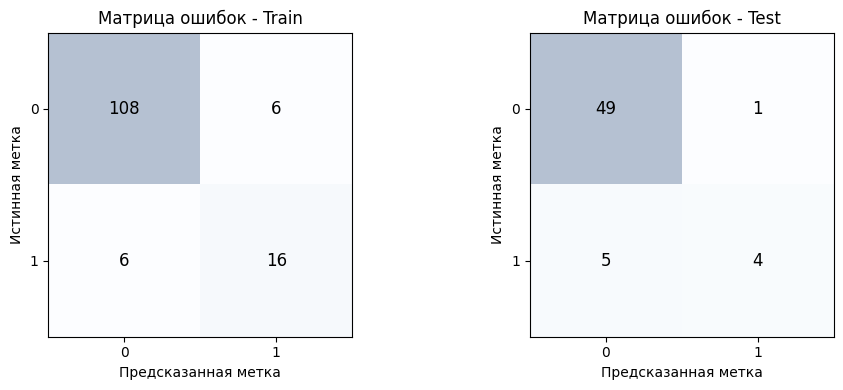

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.912 |               0.912 |               0.837 |            0.912 |            0.837 |        0.912 |        0.837 | 0.675 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.898 |               0.898 |               0.854 |            0.898 |            0.712 |        0.898 |        0.757 | 0.548 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

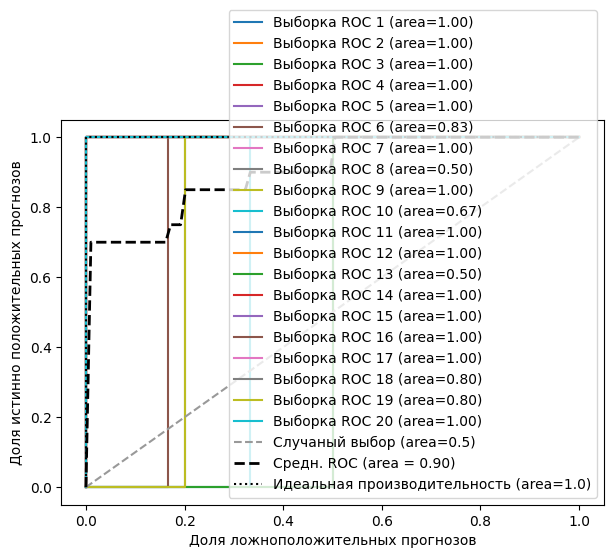

In [39]:
results = evalute_model(lr1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(lr1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

In [93]:
joblib.dump(lr, 'model_kee_classic_lr_binary_lda4.pkl')

metadata = {
    'model_type': type(lr).__name__,
    'params': lr.get_params(),
    'train_score': lr.score(X_train_lda, y_train),
    'test_score': lr.score(X_test_lda, y_test)
}
with open('metadata_kee_classic_lr_binary_lda4.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### Алгоритм k-ближайших соседей

In [35]:
knn = KNeighborsClassifier(metric='minkowski')
param_grid_knn = {
    'n_neighbors': list(range(1, 7, 2)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'p': [1, 2, 3], 
    'leaf_size': [10, 20, 30, 40, 50]
}
grid_search_for_model(knn, param_grid_knn, X_train_lda, y_train_lda)

Fitting 20 folds for each of 270 candidates, totalling 5400 fits
0.7
{'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}


In [36]:
knn = KNeighborsClassifier(algorithm = 'auto', leaf_size = 10, n_neighbors = 3, p = 1, weights = 'uniform')
knn1 = model_training(knn, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [5 2], Точн.: 1.000
Выборка: 02, Распр. кл.: [5 2], Точн.: 0.714
Выборка: 03, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 04, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 05, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 06, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 07, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 08, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 09, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 10, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 11, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 12, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 13, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 14, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 15, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 16, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 17, Распр. кл.: [5 1], Точн.: 1.000
Выборка: 18, Распр. кл.: [5 1], Точн.: 1.000
Выборка: 19, Распр. кл.: [5 1], Точн.: 0.833
Выборка: 20, Распр. кл.: [5 1], Точн.: 1.000
Точность по CV: 0.920 +/- 0.107


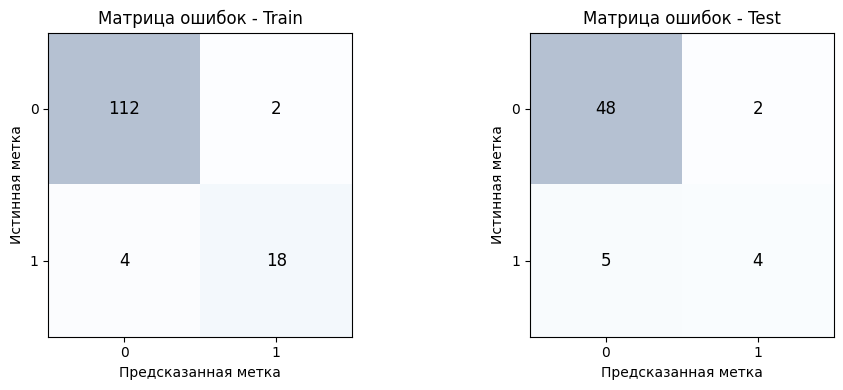

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.956 |               0.956 |               0.933 |            0.956 |            0.9   |        0.956 |        0.916 | 0.832 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.881 |               0.881 |               0.786 |            0.881 |            0.702 |        0.881 |        0.733 | 0.481 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

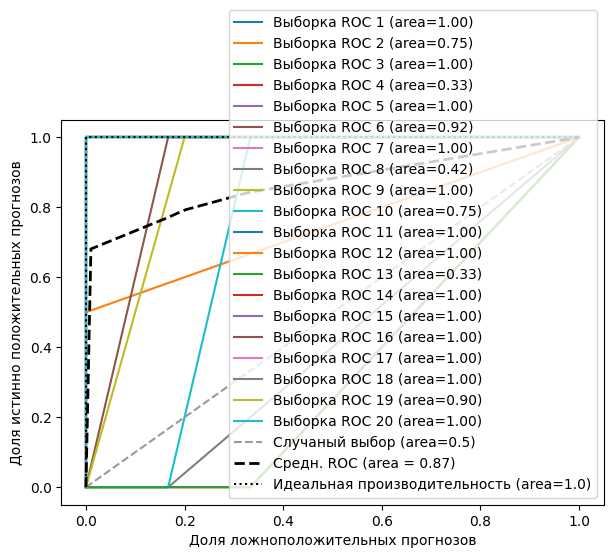

In [37]:
results = evalute_model(knn1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(knn1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

In [119]:
joblib.dump(knn, 'model_kee_classic_knn_binary_lda2.pkl')

metadata = {
    'model_type': type(knn).__name__,
    'params': knn.get_params(),
    'train_score': knn.score(X_train_lda, y_train),
    'test_score': knn.score(X_test_lda, y_test)
}
with open('metadata_kee_classic_knn_binary_lda2.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### SVM

In [40]:
svc = SVC(random_state=1)
param_grid_svc = [
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],
        'coef0': [0, 1, 2]  
    }
]
grid_search_for_model(svc, param_grid_svc, X_train_lda, y_train_lda)

Fitting 20 folds for each of 128 candidates, totalling 2560 fits
0.625
{'C': 100, 'kernel': 'linear'}


Выборка: 01, Распр. кл.: [5 2], Точн.: 1.000
Выборка: 02, Распр. кл.: [5 2], Точн.: 0.857
Выборка: 03, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 04, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 05, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 06, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 07, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 08, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 09, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 10, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 11, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 12, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 13, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 14, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 15, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 16, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 17, Распр. кл.: [5 1], Точн.: 1.000
Выборка: 18, Распр. кл.: [5 1], Точн.: 0.833
Выборка: 19, Распр. кл.: [5 1], Точн.: 0.667
Выборка: 20, Распр. кл.: [5 1], Точн.: 1.000
Точность по CV: 0.918 +/- 0.102


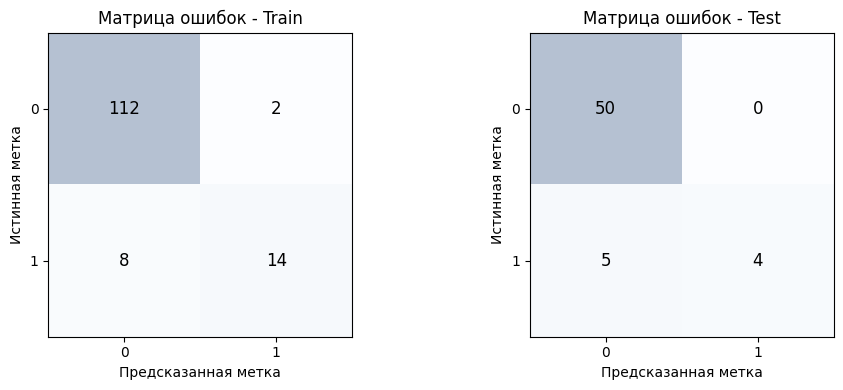

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.926 |               0.926 |               0.904 |            0.926 |            0.809 |        0.926 |        0.847 | 0.707 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.915 |               0.915 |               0.955 |            0.915 |            0.722 |        0.915 |        0.784 | 0.636 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

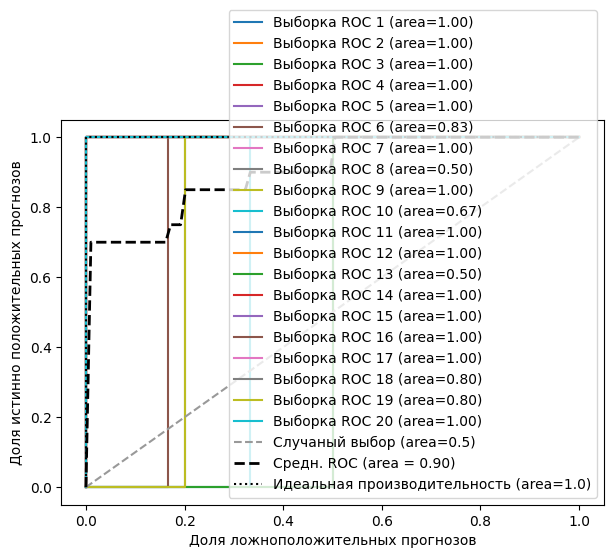

In [41]:
svc = SVC(random_state=1, C=100, kernel='linear', probability=True)
svc1 = model_training(svc, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20)
results = evalute_model(svc1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(svc1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

In [118]:
joblib.dump(svc, 'model_kee_classic_svc_binary_lda.pkl')

metadata = {
    'model_type': type(svc).__name__,
    'params': svc.get_params(),
    'train_score': svc.score(X_train_lda, y_train),
    'test_score': svc.score(X_test_lda, y_test)
}
with open('metadata_kee_classic_svc_binary_lda.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### XGBoost

In [42]:
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.8, 1.0]
}
xgbm = xgb.XGBClassifier(random_state=1)
grid_search_for_model(xgbm, param_grid_xgb, X_train_lda, y_train_lda)

Fitting 20 folds for each of 16 candidates, totalling 320 fits
0.75
{'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [43]:
xgbm = xgb.XGBClassifier(n_estimators=100, learning_rate=0.3, 
                         subsample = 0.8, max_depth=3,random_state=1)
xgbm1 = model_training(xgbm, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [5 2], Точн.: 1.000
Выборка: 02, Распр. кл.: [5 2], Точн.: 0.714
Выборка: 03, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 04, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 05, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 06, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 07, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 08, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 09, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 10, Распр. кл.: [6 1], Точн.: 0.714
Выборка: 11, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 12, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 13, Распр. кл.: [6 1], Точн.: 0.857
Выборка: 14, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 15, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 16, Распр. кл.: [6 1], Точн.: 1.000
Выборка: 17, Распр. кл.: [5 1], Точн.: 1.000
Выборка: 18, Распр. кл.: [5 1], Точн.: 0.833
Выборка: 19, Распр. кл.: [5 1], Точн.: 1.000
Выборка: 20, Распр. кл.: [5 1], Точн.: 1.000
Точность по CV: 0.920 +/- 0.107


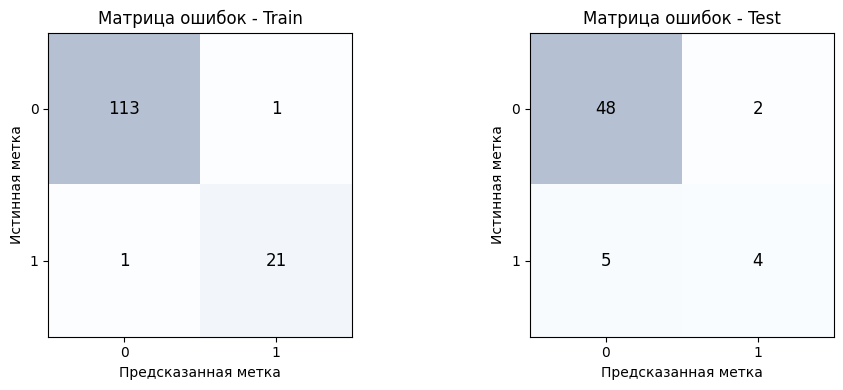

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.985 |               0.985 |               0.973 |            0.985 |            0.973 |        0.985 |        0.973 | 0.946 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.881 |               0.881 |               0.786 |            0.881 |            0.702 |        0.881 |        0.733 | 0.481 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

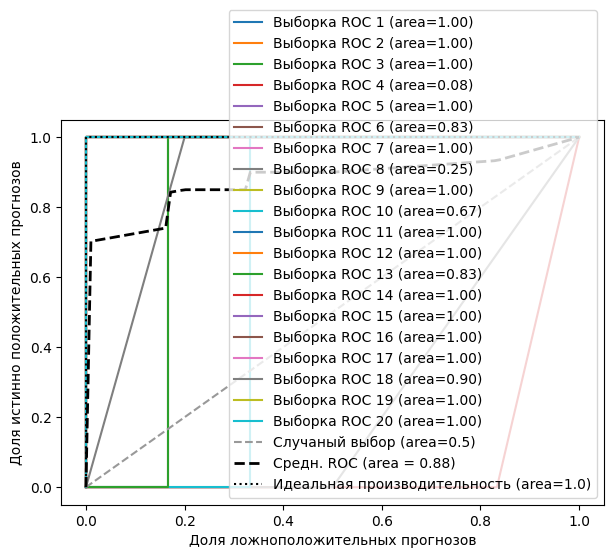

In [44]:
results = evalute_model(xgbm1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(xgbm1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

In [124]:
joblib.dump(xgbm, 'model_kee_classic_xbgm_binary_lda.pkl')

metadata = {
    'model_type': type(xgbm).__name__,
    'params': xgbm.get_params(),
    'train_score': xgbm.score(X_train_lda, y_train),
    'test_score': xgbm.score(X_test_lda, y_test)
}
with open('metadata_kee_classic_xgbm_binary_lda.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### MLP

#### 1 попытка

In [119]:
X_val_lda, X_test_lda, y_val_lda, y_test_lda = train_test_split(
    X_test_lda, y_test_lda, test_size=0.5, random_state=42, stratify=y_test_lda
)
smote = SMOTE(random_state=42, sampling_strategy=0.65)
X_train_sample, y_train_sample = smote.fit_resample(X_train_lda, y_train_lda)

In [98]:
param_grid_net = {
    'batch_size': [16, 32],
    'epochs': [30],
    'learning_rate': [0.001],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'elu'],
    'hidden_layer_sizes': [(16, 8), (32, 16), (64, 32)],
    'dropout_rate': [0.2],
    'use_batch_norm': [True],
    'l1_reg': [0.001],
    'l2_reg': [0.001]
}

best_score, best_params, all_results = manual_keras_grid_search(
    X_train_lda, y_train_lda, param_grid_net, cv=5
)

Всего комбинаций: 24

Комбинация 1/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer': 'adam', 'use_batch_norm': True}
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
  Fold 1: recall = 0.6000
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
  Fold 2: recall = 1.0000
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
  Fold 3: recall = 1.0000
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
  Fold 4: recall = 1.0000
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
  Fold 5: recall = 0.5000
  Средний recall: 0.8200

Комбинация 2/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimiz

In [120]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_lda.shape[1], )))

model.add(layers.Dense(16, 
                      activation='elu',
                      kernel_regularizer=regularizers.l1_l2(0.01)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(8, activation='elu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(4, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))

model.add(layers.Dense(2, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=30, batch_size=16, validation_data=(X_val_lda, y_val_lda))

Epoch 1/30
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:31 8s/step - accuracy: 0.5000 - loss: 0.7986 - precision: 0.4444 - recall: 0.5714
121m 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5588 - loss: 0.7807 - precision: 0.4413 - recall: 0.5858
121m12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5940 - loss: 0.7462 - precision: 0.4814 - recall: 0.6193
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.5978 - loss: 0.7427 - precision: 0.4859 - recall: 0.6205 - val_accuracy: 0.8621 - val_loss: 0.6847 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9375 - loss: 0.4531 - precision: 1.0000 - recall: 0.8750
121m 6/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8005 - loss: 0.5634 - precision: 0.7534 - recall: 0.7354
121m11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7662 - loss: 0.5897 - precision: 0.7078 - recall: 0.6847
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7596 - loss: 0.5941 

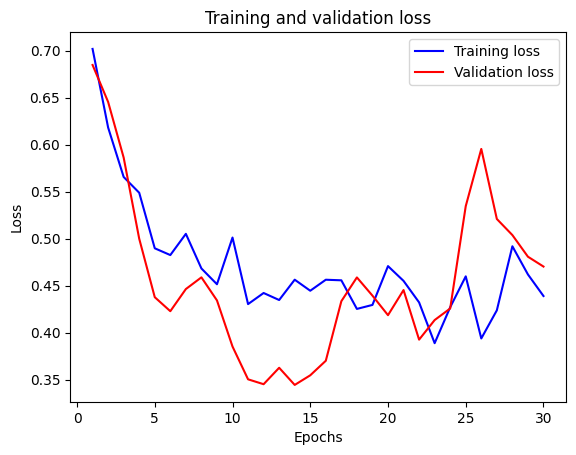

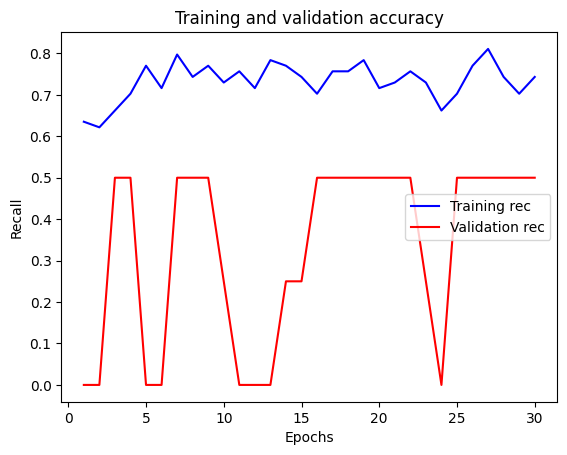

<Figure size 640x480 with 0 Axes>

In [121]:
history_dict = history.history
epochs = range(1, 31)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training rec')
plt.plot(epochs, val_acc_values, 'r', label='Validation rec')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()
plt.clf()

In [122]:
data = {
            "Train": (X_train_lda, y_train_lda),
            "Validation": (X_val_lda, y_val_lda),
            "Test": (X_test_lda, y_test_lda)
        }

5
51/5 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step
55/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


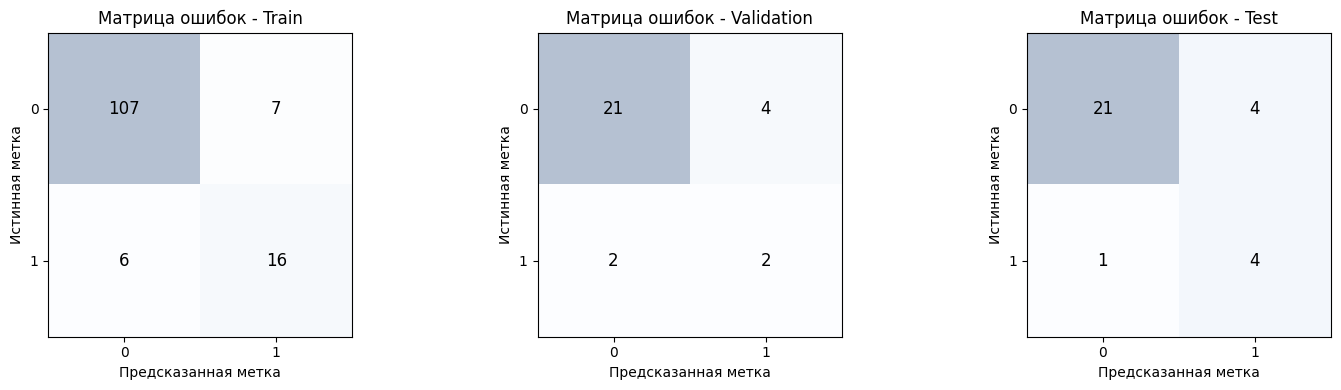

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.904 |               0.904 |               0.821 |            0.904 |            0.833 |        0.904 |        0.827 | 0.654 |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.793 |               0.793 |               0.623 |            0.793 |            0.67  |        0.793 |        0.637 | 0.289 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

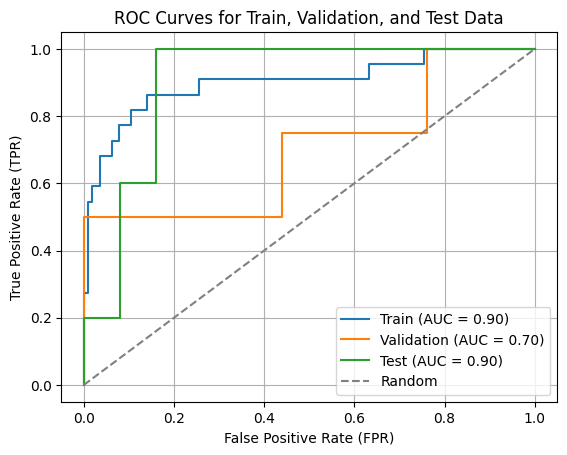

In [123]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [125]:
joblib.dump(lda, 'lda_kee_classic_final1.pkl')
model.save('neural_net_model_kee_classic_lda_final1.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_classic_lda_binary_final1.json', 'w') as f:
    json.dump(metadata, f, indent=4)

#### 2 попытка

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)
lda = LDA(solver= 'svd')
y_train_lda = y_train.values.ravel()
y_test_lda = y_test.values.ravel()
X_train_lda = lda.fit_transform(X_train, y_train_lda)
X_test_lda = lda.transform(X_test)
data = {"Train": (X_train_lda, y_train_lda),
        "Test": (X_test_lda, y_test_lda)}
X_val_lda, X_test_lda, y_val_lda, y_test_lda = train_test_split(
    X_test_lda, y_test_lda, test_size=0.5, random_state=42, stratify=y_test_lda
)
smote = SMOTE(random_state=42, sampling_strategy=0.65)
X_train_sample, y_train_sample = smote.fit_resample(X_train_lda, y_train_lda)

In [142]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_lda.shape[1], )))

model.add(layers.Dense(64, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(32, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=40, batch_size=16, validation_data=(X_val_lda, y_val_lda))

Epoch 1/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:43 9s/step - accuracy: 0.3125 - loss: 1.4017 - precision: 0.2500 - recall: 0.2857
121m 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4455 - loss: 1.2500 - precision: 0.3286 - recall: 0.4478 
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.5099 - loss: 1.1778 - precision: 0.3997 - recall: 0.5182 - val_accuracy: 0.8621 - val_loss: 0.9117 - val_precision: 0.5000 - val_recall: 0.7500
Epoch 2/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8750 - loss: 0.8094 - precision: 0.7500 - recall: 1.0000
121m 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8521 - loss: 0.8358 - precision: 0.7769 - recall: 0.8785
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8443 - loss: 0.8354 - precision: 0.7887 - recall: 0.8362 - val_accuracy: 0.8966 - val_loss: 0.7780 - val_precision: 0.5714 - val_recall: 1.0000
Epoch 3/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.8750 - loss: 0.7133 - precision: 1.0000 -

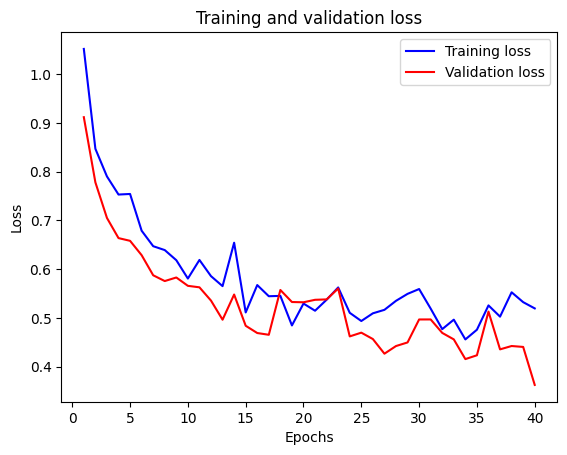

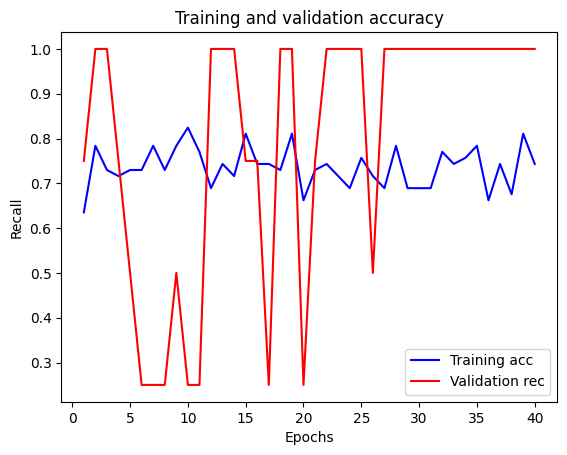

<Figure size 640x480 with 0 Axes>

In [143]:
history_dict = history.history
epochs = range(1, 41)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training acc')
plt.plot(epochs, val_acc_values, 'r', label='Validation rec')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()
plt.clf()

In [144]:
data = {
            "Train": (X_train_lda, y_train_lda),
            "Validation": (X_val_lda, y_val_lda),
            "Test": (X_test_lda, y_test_lda)
        }

5
51/5 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step
55/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


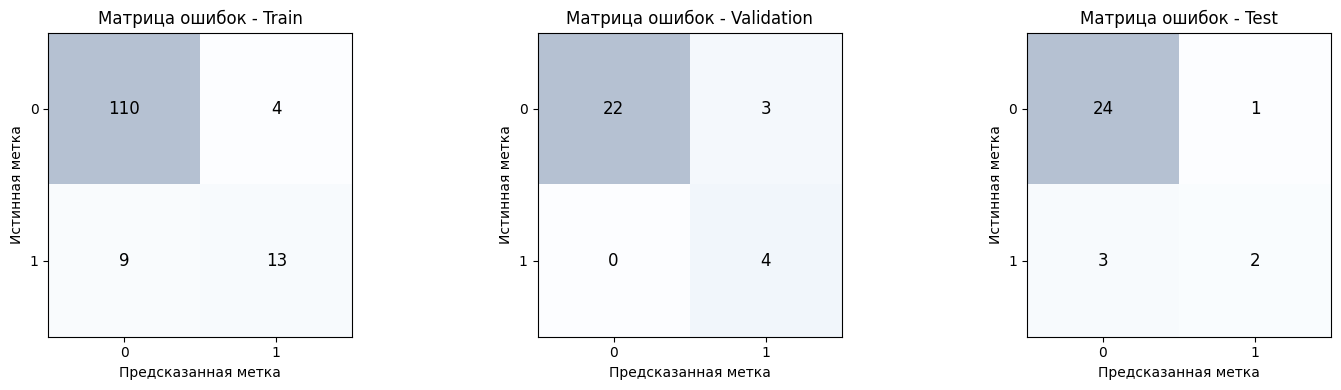

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.904 |               0.904 |               0.845 |            0.904 |            0.778 |        0.904 |        0.805 | 0.619 |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.897 |               0.897 |               0.786 |            0.897 |            0.94  |        0.897 |        0.832 | 0.709 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

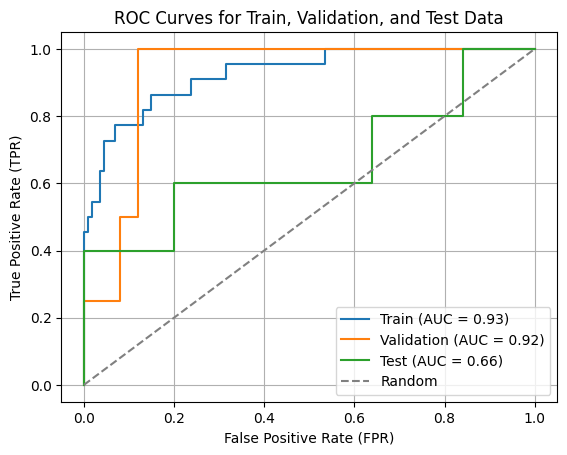

In [145]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [146]:
joblib.dump(lda, 'lda_kee_classic_final_good.pkl')
model.save('neural_net_model_kee_classic_lda_final_good.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_classic_lda_binary_final_good.json', 'w') as f:
    json.dump(metadata, f, indent=4)

#### 3 попытка

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)
lda = LDA(solver= 'svd')
y_train_lda = y_train.values.ravel()
y_test_lda = y_test.values.ravel()
X_train_lda = lda.fit_transform(X_train, y_train_lda)
X_test_lda = lda.transform(X_test)
data = {"Train": (X_train_lda, y_train_lda),
        "Test": (X_test_lda, y_test_lda)}
X_val_lda, X_test_lda, y_val_lda, y_test_lda = train_test_split(
    X_test_lda, y_test_lda, test_size=0.5, random_state=42, stratify=y_test_lda
)
smote = SMOTE(random_state=42, sampling_strategy=0.65)
X_train_sample, y_train_sample = smote.fit_resample(X_train_lda, y_train_lda)

In [148]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_lda.shape[1], )))

model.add(layers.Dense(64, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(32, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=40, batch_size=16, validation_data=(X_val_lda, y_val_lda))

Epoch 1/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:36 9s/step - accuracy: 0.5000 - loss: 1.1730 - precision: 0.4444 - recall: 0.5714
121m 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6132 - loss: 1.0618 - precision: 0.5122 - recall: 0.6162 
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.6478 - loss: 1.0192 - precision: 0.5508 - recall: 0.6367 - val_accuracy: 0.7586 - val_loss: 0.9523 - val_precision: 0.2857 - val_recall: 0.5000
Epoch 2/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8125 - loss: 0.8459 - precision: 0.8571 - recall: 0.7500
121m 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8622 - loss: 0.7873 - precision: 0.9319 - recall: 0.7799 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8635 - loss: 0.7809 - precision: 0.9056 - recall: 0.7876 - val_accuracy: 0.7586 - val_loss: 0.8713 - val_precision: 0.2857 - val_recall: 0.5000
Epoch 3/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.5582 - precision: 1.0000 - 

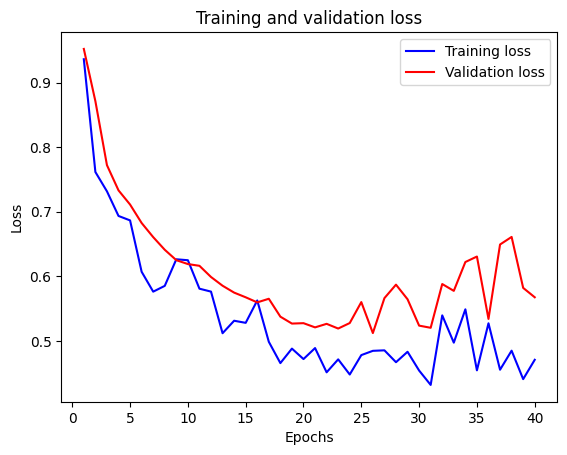

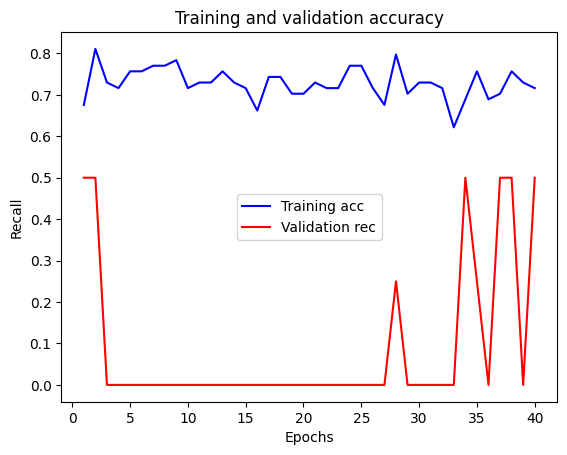

<Figure size 640x480 with 0 Axes>

In [149]:
history_dict = history.history
epochs = range(1, 41)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training acc')
plt.plot(epochs, val_acc_values, 'r', label='Validation rec')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()
plt.clf()

In [150]:
data = {
            "Train": (X_train_lda, y_train_lda),
            "Validation": (X_val_lda, y_val_lda),
            "Test": (X_test_lda, y_test_lda)
        }

5
51/5 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step
55/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


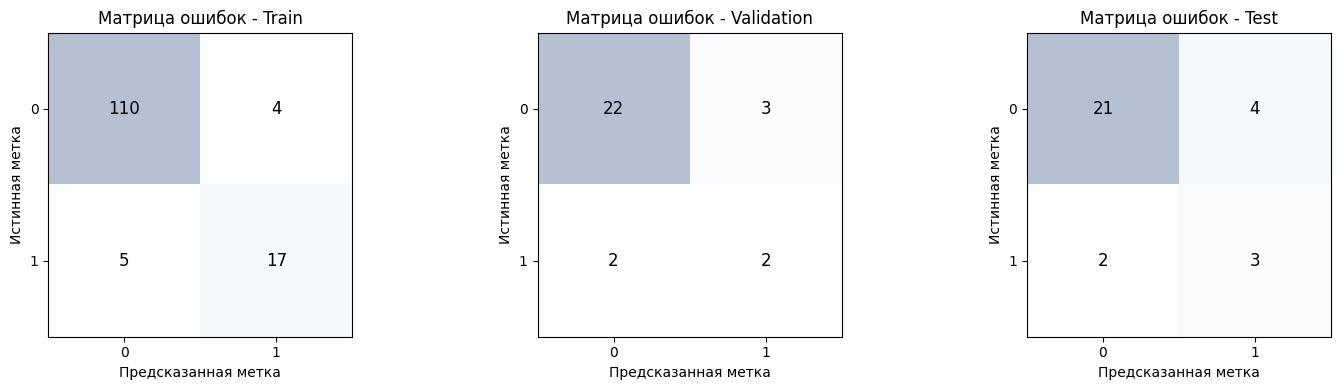

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.934 |               0.934 |               0.883 |            0.934 |            0.869 |        0.934 |        0.876 | 0.752 |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.828 |               0.828 |               0.658 |            0.828 |            0.69  |        0.828 |        0.671 | 0.347 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

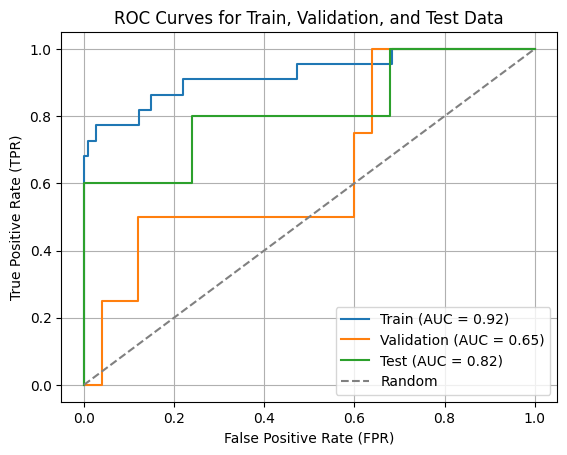

In [151]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [152]:
joblib.dump(lda, 'lda_kee_classic_final_good2.pkl')
model.save('neural_net_model_kee_classic_lda_final_good2.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_classic_lda_binary_final_good2.json', 'w') as f:
    json.dump(metadata, f, indent=4)

#### 4 попытка

In [192]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)
lda = LDA(solver= 'svd')
y_train_lda = y_train.values.ravel()
y_test_lda = y_test.values.ravel()
X_train_lda = lda.fit_transform(X_train, y_train_lda)
X_test_lda = lda.transform(X_test)
data = {"Train": (X_train_lda, y_train_lda),
        "Test": (X_test_lda, y_test_lda)}
X_val_lda, X_test_lda, y_val_lda, y_test_lda = train_test_split(
    X_test_lda, y_test_lda, test_size=0.5, random_state=42, stratify=y_test_lda
)
smote = SMOTE(random_state=42, sampling_strategy=0.65)
X_train_sample, y_train_sample = smote.fit_resample(X_train_lda, y_train_lda)

In [193]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_lda.shape[1], )))

model.add(layers.Dense(64, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(32, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=40, batch_size=16, validation_data=(X_val_lda, y_val_lda))

Epoch 1/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:35 9s/step - accuracy: 0.5000 - loss: 1.5547 - precision: 0.3333 - recall: 0.3333
121m 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7397 - loss: 1.0759 - precision: 0.6892 - recall: 0.6262 
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.7658 - loss: 1.0140 - precision: 0.7230 - recall: 0.6576 - val_accuracy: 0.7586 - val_loss: 0.9989 - val_precision: 0.3333 - val_recall: 0.7500
Epoch 2/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9375 - loss: 0.6126 - precision: 1.0000 - recall: 0.8333
121m 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8758 - loss: 0.7169 - precision: 0.9209 - recall: 0.7577 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8738 - loss: 0.7193 - precision: 0.9020 - recall: 0.7723 - val_accuracy: 0.7586 - val_loss: 0.9210 - val_precision: 0.3333 - val_recall: 0.7500
Epoch 3/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8125 - loss: 0.9188 - precision: 0.5000 - 

In [194]:
data = {
            "Train": (X_train_lda, y_train_lda),
            "Validation": (X_val_lda, y_val_lda),
            "Test": (X_test_lda, y_test_lda)
        }

5
51/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


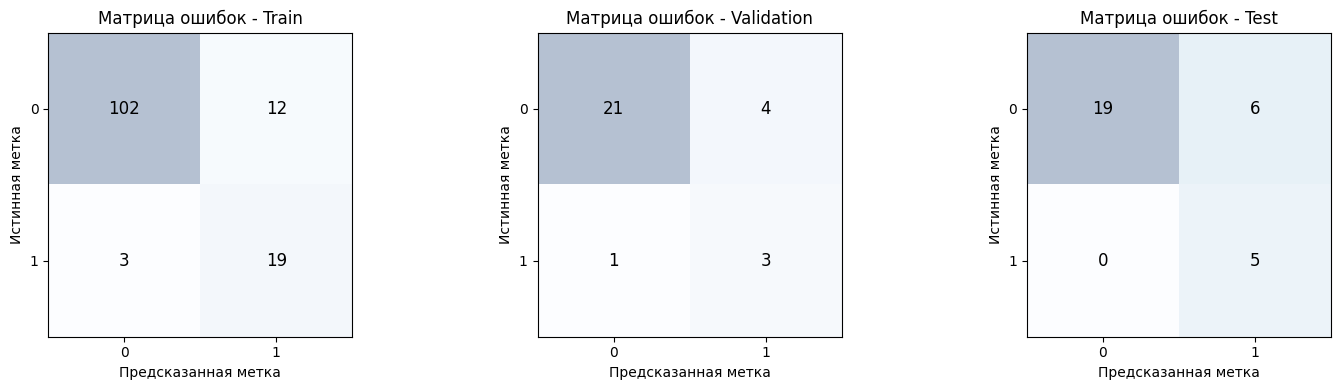

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.89  |               0.89  |               0.792 |            0.89  |            0.879 |        0.89  |        0.824 | 0.666 |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.828 |               0.828 |               0.692 |            0.828 |            0.795 |        0.828 |        0.72  | 0.475 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

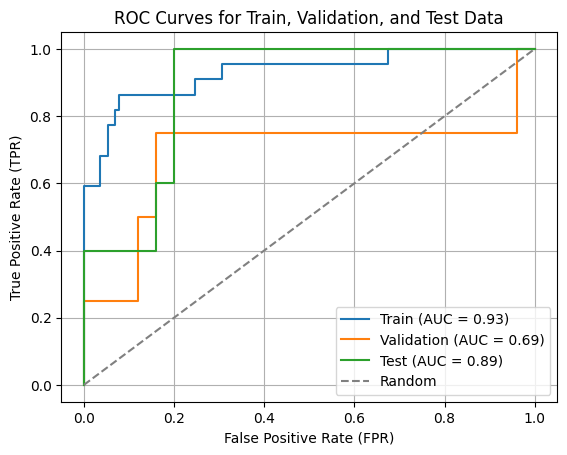

In [196]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [197]:
joblib.dump(lda, 'lda_kee_classic_final_best.pkl')
model.save('neural_net_model_kee_classic_lda_final_best.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_classic_lda_binary_final_best.json', 'w') as f:
    json.dump(metadata, f, indent=4)

#### 5 попытка

In [195]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_lda.shape[1], )))

model.add(layers.Dense(64, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(32, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=40, batch_size=16, validation_data=(X_val_lda, y_val_lda))

Epoch 1/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 2:15 12s/step - accuracy: 0.2500 - loss: 1.4832 - precision: 0.2222 - recall: 0.2857
121m 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4473 - loss: 1.2454 - precision: 0.3503 - recall: 0.4052  
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.5350 - loss: 1.1387 - precision: 0.4410 - recall: 0.4612 - val_accuracy: 0.7931 - val_loss: 0.9630 - val_precision: 0.3750 - val_recall: 0.7500
Epoch 2/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5625 - loss: 1.1804 - precision: 0.3333 - recall: 0.4000
121m 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7314 - loss: 0.9464 - precision: 0.6437 - recall: 0.6387
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7531 - loss: 0.9181 - precision: 0.6822 - recall: 0.6648 - val_accuracy: 0.8276 - val_loss: 0.8335 - val_precision: 0.4286 - val_recall: 0.7500
Epoch 3/40
12
121m 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8125 - loss: 0.8578 - precision: 0.7143 - 

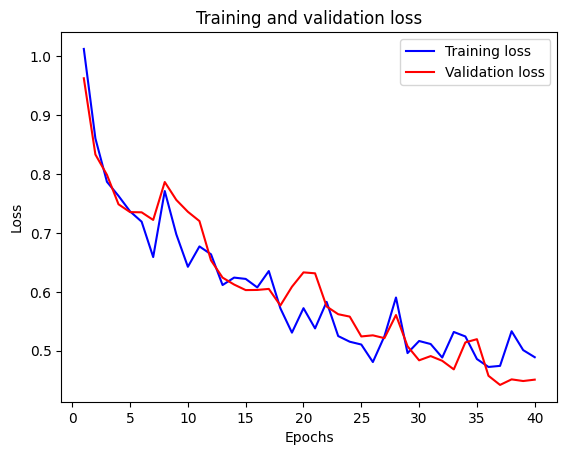

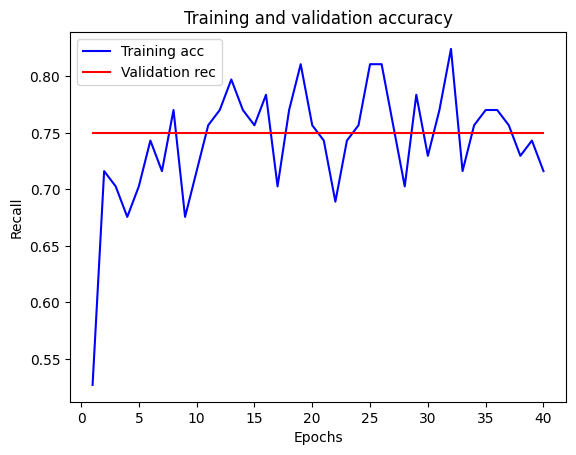

<Figure size 640x480 with 0 Axes>

In [196]:
history_dict = history.history
epochs = range(1, 41)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training acc')
plt.plot(epochs, val_acc_values, 'r', label='Validation rec')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()
plt.clf()

In [197]:
data = {
            "Train": (X_train_lda, y_train_lda),
            "Validation": (X_val_lda, y_val_lda),
            "Test": (X_test_lda, y_test_lda)
        }

5
51/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
55/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1
11/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


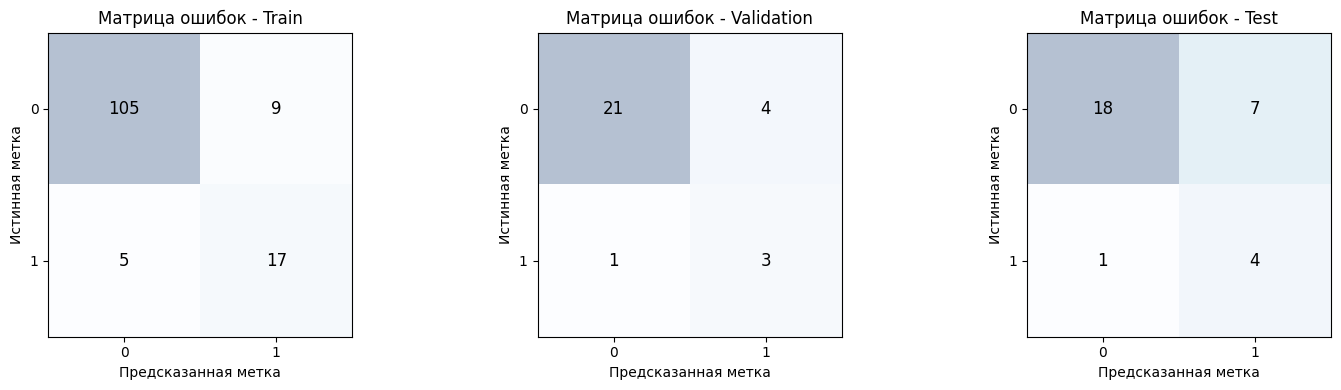

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.897 |               0.897 |               0.804 |            0.897 |            0.847 |        0.897 |        0.823 | 0.65  |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.828 |               0.828 |               0.692 |            0.828 |            0.795 |        0.828 |        0.72  | 0.475 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

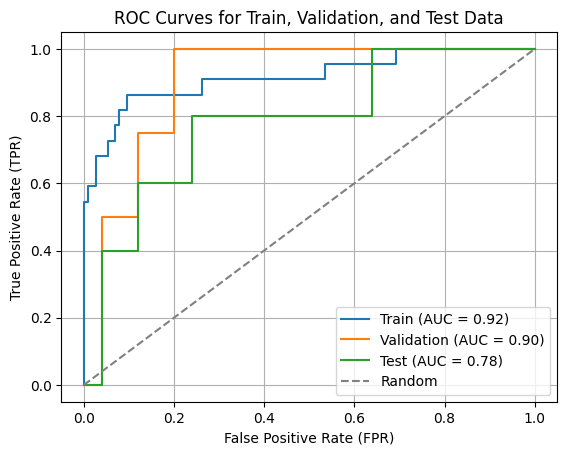

In [198]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [199]:
joblib.dump(lda, 'lda_kee_classic_final_best.pkl')
model.save('neural_net_model_kee_classic_lda_final_best2.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_classic_lda_binary_final_best.json', 'w') as f:
    json.dump(metadata, f, indent=4)